In [7]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)

TensorFlow version: 2.21.0
OpenCV version: 4.13.0


In [8]:
PROJECT_DIR = Path(r"C:\Users\mpste\CPSC483_Project")

DATASET_DIR = PROJECT_DIR / "data" / "DATASET"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = PROJECT_DIR / "models"
LOG_DIR = PROJECT_DIR / "logs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

if TRAIN_DIR.exists():
    print("Train folders:", sorted(os.listdir(TRAIN_DIR)))

if TEST_DIR.exists():
    print("Test folders:", sorted(os.listdir(TEST_DIR)))

Project directory: C:\Users\mpste\CPSC483_Project
Dataset directory: C:\Users\mpste\CPSC483_Project\data\DATASET
Train exists: True
Test exists: True
Train folders: ['1', '2', '3', '4', '5', '6', '7']
Test folders: ['1', '2', '3', '4', '5', '6', '7']


In [9]:
emotion_map = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sad",
    "6": "angry",
    "7": "neutral"
}

class_names = [
    "surprise",
    "fear",
    "disgust",
    "happy",
    "sad",
    "angry",
    "neutral"
]

print("Emotion classes:")
for key, value in emotion_map.items():
    print(key, "=", value)

Emotion classes:
1 = surprise
2 = fear
3 = disgust
4 = happy
5 = sad
6 = angry
7 = neutral


In [10]:
def count_images(folder):
    rows = []

    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            image_files = [
                f for f in class_folder.glob("*")
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            ]

            rows.append({
                "folder_label": class_folder.name,
                "emotion": emotion_map.get(class_folder.name, "unknown"),
                "count": len(image_files)
            })

    return pd.DataFrame(rows)


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
display(train_counts)

print("Testing images:")
display(test_counts)

print("Total train images:", train_counts["count"].sum())
print("Total test images:", test_counts["count"].sum())

Training images:


,folder_label,emotion,count
0,1,surprise,1290
1,2,fear,281
2,3,disgust,717
3,4,happy,4772
4,5,sad,1982
5,6,angry,705
6,7,neutral,2524


Testing images:


,folder_label,emotion,count
0,1,surprise,329
1,2,fear,74
2,3,disgust,160
3,4,happy,1185
4,5,sad,478
5,6,angry,162
6,7,neutral,680


Total train images: 12271
Total test images: 3068


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

print("Class indices from Keras:")
print(train_gen.class_indices)

Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Class indices from Keras:
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [12]:
index_to_folder = {v: k for k, v in train_gen.class_indices.items()}
index_to_emotion = {
    index: emotion_map[folder]
    for index, folder in index_to_folder.items()
}

emotion_labels = [
    index_to_emotion[i]
    for i in range(len(index_to_emotion))
]

print("Index to folder:")
print(index_to_folder)

print("Index to emotion:")
print(index_to_emotion)

print("Final emotion label order:")
print(emotion_labels)

Index to folder:
{0: '1', 1: '2', 2: '3', 3: '4', 4: '5', 5: '6', 6: '7'}
Index to emotion:
{0: 'surprise', 1: 'fear', 2: 'disgust', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'neutral'}
Final emotion label order:
['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


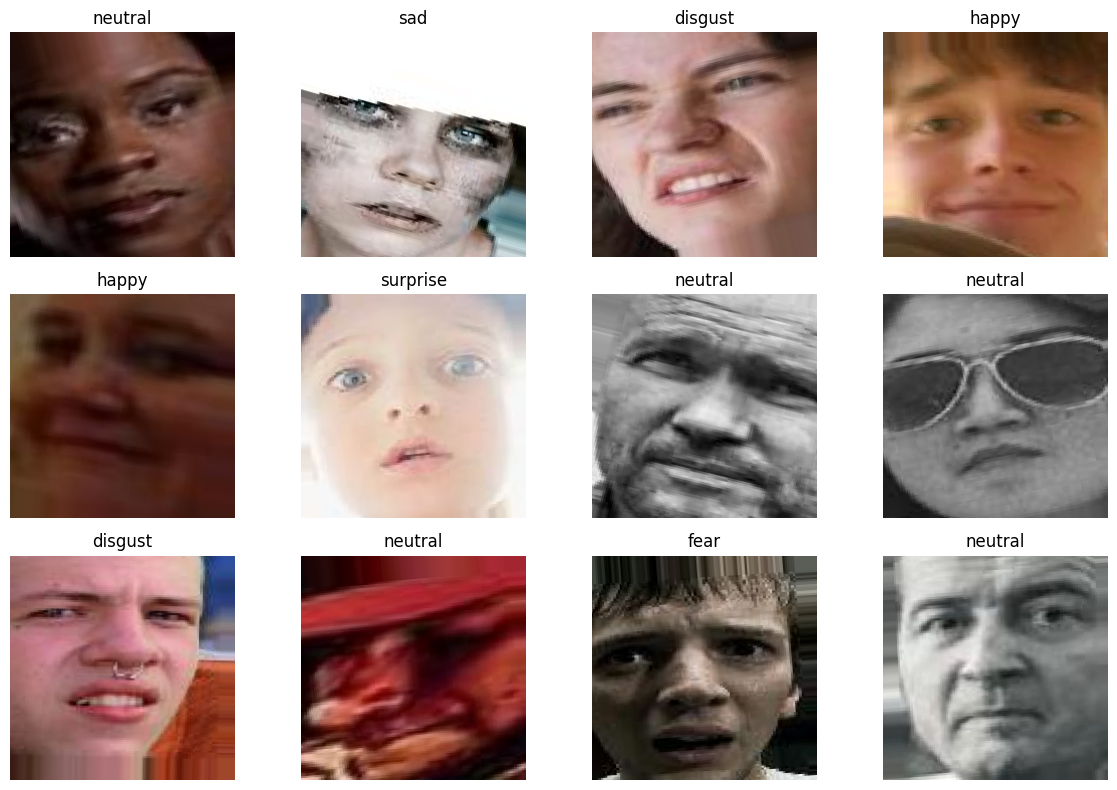

In [13]:
batch_images, batch_labels = next(train_gen)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # MobileNetV2 preprocessing changes image range to [-1, 1].
    # Convert back to [0, 1] for display.
    img = (batch_images[i] + 1.0) / 2.0
    img = np.clip(img, 0, 1)

    label_index = int(batch_labels[i])
    label_name = emotion_labels[label_index]

    plt.imshow(img)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
y_train = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train), class_weights_array)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 1.3589147286821706, 1: 6.238434163701068, 2: 2.4449093444909344, 3: 0.3673512154233026, 4: 0.884460141271443, 5: 2.4865248226950354, 6: 0.6945324881141046}


In [15]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.45)(x)

outputs = layers.Dense(7, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [19]:
EPOCHS = 12

checkpoint_path = MODEL_DIR / "best_rafdb_emotion_model.keras"

callbacks = [
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3073 - loss: 2.3152
Epoch 1: val_accuracy improved from None to 0.45404, saving model to C:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 786s 2s/step - accuracy: 0.3324 - loss: 2.1337 - val_accuracy: 0.4540 - val_loss: 1.4725 - learning_rate: 0.0010
Epoch 2/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.3931 - loss: 1.6569
Epoch 2: val_accuracy improved from 0.45404 to 0.52510, saving model to C:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.4082 - loss: 1.6188 - val_accuracy: 0.5251 - val_loss: 1.3152 - learning_rate: 0.0010
Epoch 3/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.4434 - loss: 1.4867
Epoch 3: val_accuracy did not improve from 0.52510
384/384 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.4389 - loss: 1.4841 - val_accuracy: 0.5173 - val_loss: 1.3081 - learn

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.332410,2.133748,0.454042,1.472450,0.00100
1,0.408198,1.618803,0.525098,1.315183,0.00100
2,0.438921,1.484083,0.517275,1.308090,0.00100
3,0.459865,1.409252,0.514342,1.330666,0.00100
4,0.465814,1.395887,0.480443,1.381828,0.00100
5,0.490506,1.293978,0.537158,1.270739,0.00030
6,0.508679,1.258159,0.537158,1.267044,0.00030
7,0.516421,1.235383,0.544329,1.254326,0.00030
8,0.512428,1.244904,0.555737,1.222413,0.00030
9,0.526933,1.200022,0.540417,1.243908,0.00030


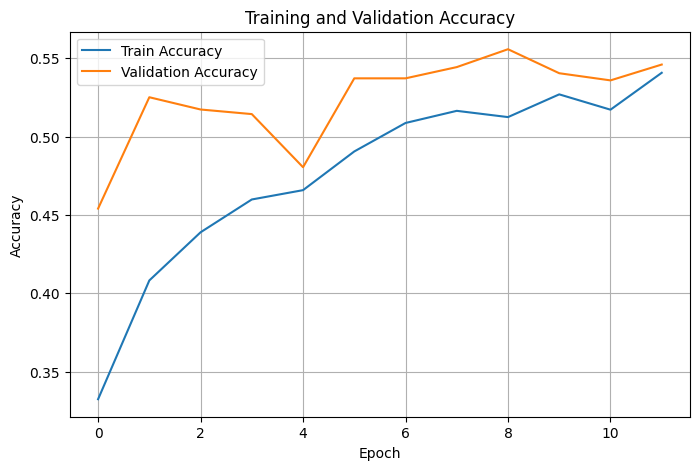

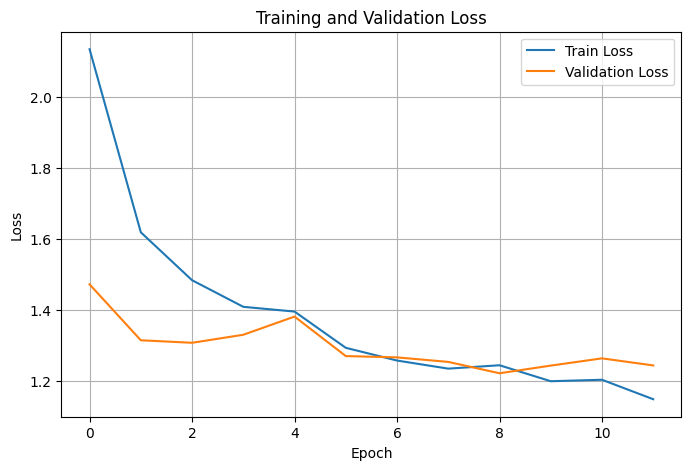

In [21]:
history_df = pd.DataFrame(history.history)

display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

fine_tune_history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.5413 - loss: 1.1706
Epoch 1: val_accuracy did not improve from 0.55574
384/384 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.5397 - loss: 1.1822 - val_accuracy: 0.5541 - val_loss: 1.2215 - learning_rate: 1.0000e-05
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.5381 - loss: 1.1800
Epoch 2: val_accuracy did not improve from 0.55574
384/384 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.5370 - loss: 1.1858 - val_accuracy: 0.5551 - val_loss: 1.2218 - learning_rate: 1.0000e-05
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.5341 - loss: 1.1795
Epoch 3: val_accuracy did not improve from 0.55574

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
384/384 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.5290 - loss: 1.1826 - val_accuracy: 0.5535 - val_loss: 1.2267 - learning_rate: 1.0000e-05
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.545

In [23]:
if checkpoint_path.exists():
    model = tf.keras.models.load_model(checkpoint_path)
    print("Loaded best checkpoint:", checkpoint_path)

test_loss, test_accuracy = model.evaluate(test_gen)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Loaded best checkpoint: C:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 723ms/step - accuracy: 0.5557 - loss: 1.2224
Test loss: 1.2224127054214478
Test accuracy: 0.5557366609573364


96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 730ms/step
Classification Report:
              precision    recall  f1-score   support

    surprise       0.51      0.55      0.53       329
        fear       0.26      0.46      0.33        74
     disgust       0.22      0.24      0.23       160
       happy       0.70      0.74      0.72      1185
         sad       0.51      0.47      0.49       478
       angry       0.36      0.50      0.42       162
     neutral       0.55      0.40      0.46       680

    accuracy                           0.56      3068
   macro avg       0.44      0.48      0.45      3068
weighted avg       0.56      0.56      0.55      3068



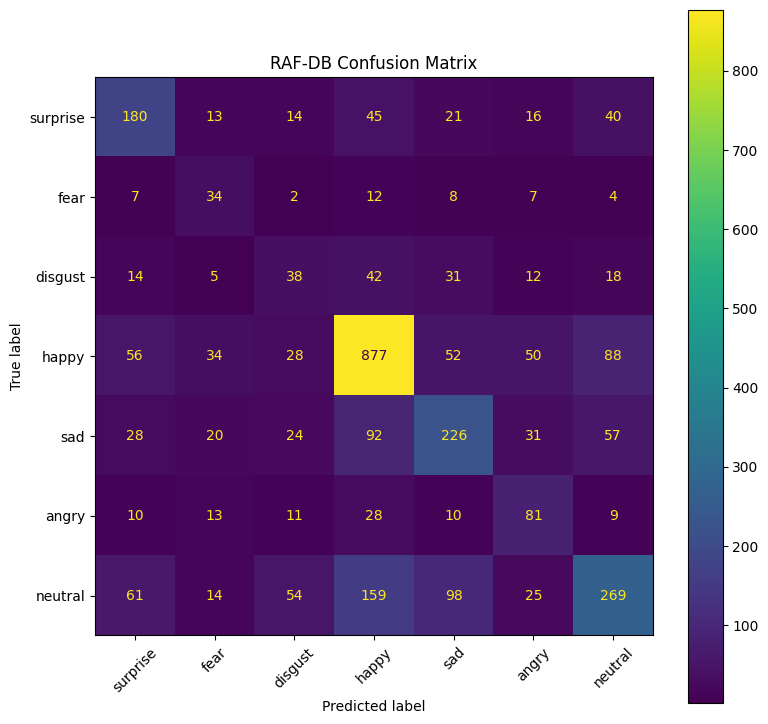

In [24]:
test_gen.reset()

pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=emotion_labels
    )
)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=emotion_labels
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("RAF-DB Confusion Matrix")
plt.show()

In [25]:
final_model_path = MODEL_DIR / "rafdb_emotion_model.keras"
label_path = MODEL_DIR / "emotion_labels.txt"
label_json_path = MODEL_DIR / "emotion_labels.json"

model.save(final_model_path)

with open(label_path, "w", encoding="utf-8") as f:
    for label in emotion_labels:
        f.write(label + "\n")

with open(label_json_path, "w", encoding="utf-8") as f:
    json.dump(emotion_labels, f, indent=4)

print("Saved model to:", final_model_path)
print("Saved labels to:", label_path)
print("Saved labels JSON to:", label_json_path)

Saved model to: C:\Users\mpste\CPSC483_Project\models\rafdb_emotion_model.keras
Saved labels to: C:\Users\mpste\CPSC483_Project\models\emotion_labels.txt
Saved labels JSON to: C:\Users\mpste\CPSC483_Project\models\emotion_labels.json


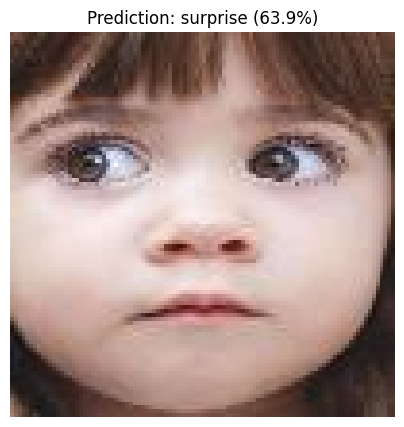

Image: C:\Users\mpste\CPSC483_Project\data\DATASET\test\1\test_0002_aligned.jpg
Predicted emotion: surprise
Confidence: 0.6386153101921082


In [26]:
def predict_single_image(image_path):
    img_bgr = cv2.imread(str(image_path))

    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    x = np.expand_dims(resized.astype(np.float32), axis=0)
    x = preprocess_input(x)

    probs = model.predict(x, verbose=0)[0]
    pred_index = int(np.argmax(probs))

    predicted_emotion = emotion_labels[pred_index]
    confidence = float(probs[pred_index])

    return predicted_emotion, confidence, img_rgb


sample_image = None

for folder in sorted(TEST_DIR.iterdir()):
    if folder.is_dir():
        image_list = [
            p for p in folder.glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        ]

        if image_list:
            sample_image = image_list[0]
            break

emotion, confidence, img = predict_single_image(sample_image)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {emotion} ({confidence * 100:.1f}%)")
plt.axis("off")
plt.show()

print("Image:", sample_image)
print("Predicted emotion:", emotion)
print("Confidence:", confidence)